# Importing Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Loading Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

<Figure size 640x480 with 0 Axes>

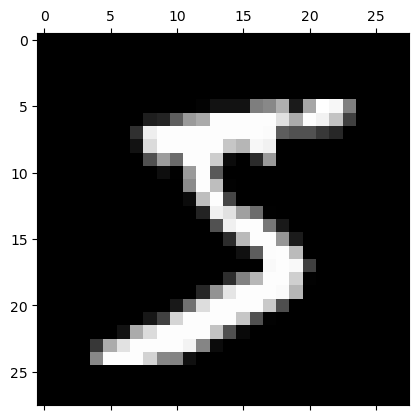

In [5]:
plt.gray()
plt.matshow(x_train[0])

In [7]:
y_train[0]

5

# Scaling

In [9]:
x_train = x_train/255 # without scaling the model perform worse
x_test = x_test/255

# Reshaping

We are reshaping, so that we can give this as an input the neuron/perceptron

In [19]:
x_train_flattened = x_train.reshape(len(x_train),28*28)
x_test_flattened = x_test.reshape(len(x_test),28*28)

In [21]:
x_train_flattened.shape

(60000, 784)

# Model Building and Training

In [23]:
model = keras.Sequential([ # Sequential = stack of layers
    keras.layers.Dense(10, input_shape=(784,),activation='sigmoid')# every node in this layer is connected to every other node in the next layer
]) # simple NN with only 2 layers, input layer and an output layer. inputs = 784, 10 neurons, outputs = 10(each neuron produce one output)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_flattened, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8056 - loss: 0.7232
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9147 - loss: 0.3043
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9201 - loss: 0.2891
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9244 - loss: 0.2675
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9270 - loss: 0.2606


# Evaluation

In [25]:
model.evaluate(x_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9150 - loss: 0.3024


[0.2666996121406555, 0.9253000020980835]

# Prediction

In [30]:
y_predicted = model.predict(x_test_flattened)
y_predicted[0] # probability score of each number which can be is returned

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2.1800959e-02, 2.2827750e-07, 7.1413778e-02, 9.5429385e-01,
       2.4140575e-03, 1.4210288e-01, 1.6698956e-06, 9.9986076e-01,
       9.3937203e-02, 6.9649184e-01], dtype=float32)

In [88]:
np.argmax(y_predicted[15])

5

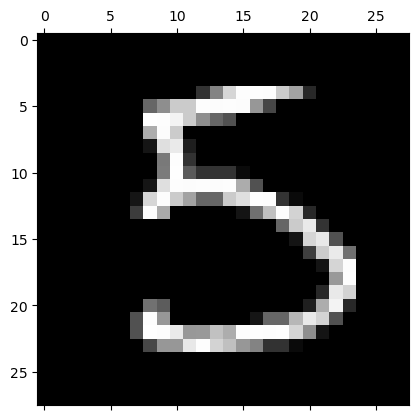

In [86]:
plt.matshow(x_test[15])

4 April 2025, 5 PM

# Confusion Matrix

In [47]:
y_test[:5] # correct labels

array([7, 2, 1, 0, 4], dtype=uint8)

In [49]:
y_predicted # for each prediction, it will give us set of 10 predictions and we'll use argmax method to find the predicted one, so we can't directly pass this
y_predicted_label = [np.argmax(i) for i in y_predicted] # list comprehension, where for every y_predicted, we are applying argmax function to get one output for each input
y_predicted_label[:5]

[7, 2, 1, 0, 4]

In [51]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_label)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 961,    0,    2,    2,    0,    5,    7,    2,    1,    0],
       [   0, 1109,    3,    2,    1,    1,    4,    2,   13,    0],
       [   4,    9,  920,   18,    8,    5,   12,   12,   42,    2],
       [   4,    0,   17,  927,    0,   18,    2,   12,   23,    7],
       [   2,    1,    6,    2,  912,    0,    8,    4,    9,   38],
       [   9,    1,    2,   39,   10,  767,   18,    8,   32,    6],
       [  10,    3,    6,    2,    8,   12,  912,    2,    3,    0],
       [   1,    5,   21,    8,    6,    1,    0,  954,    2,   30],
       [   5,    7,    7,   20,    9,   20,   10,   12,  877,    7],
       [  10,    7,    1,    8,   29,    7,    0,   26,    7,  914]])>

Text(95.72222222222221, 0.5, 'Truth')

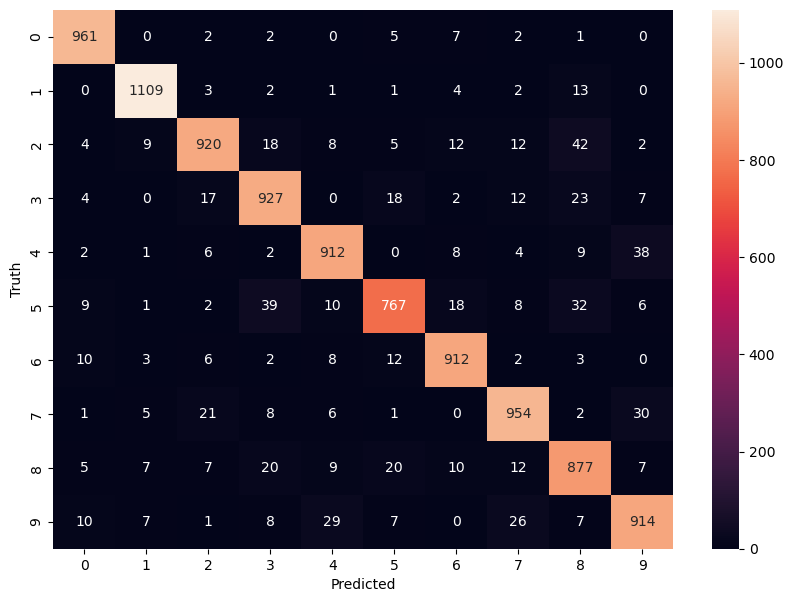

In [53]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# Adding Hidden layer

In [56]:
model = keras.Sequential([ # Sequential = stack of layers
    # adding one hidden layer
    keras.layers.Dense(100, input_shape=(784,),activation='relu'), # hidden layer, 784 inputs(from input layer), 100 neurons in hidden layer, 100 outputs
    keras.layers.Dense(10, activation='sigmoid') # output layer, no need to mention inputs(it will automatically gets it from previous layer = 100), 10 neurons, 10 outputs 
])  
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_flattened, y_train, epochs=5)

C:\Users\syamp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8743 - loss: 0.4519
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9621 - loss: 0.1324
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9741 - loss: 0.0885
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9799 - loss: 0.0676
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9848 - loss: 0.0512


# Evaluation of new model

In [62]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9717 - loss: 0.0925


[0.08121798932552338, 0.975600004196167]

By adding a hidden layer our accuracy increased from 91.5% to 97.2%

# Confusion Matrix for new model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Text(95.72222222222221, 0.5, 'Truth')

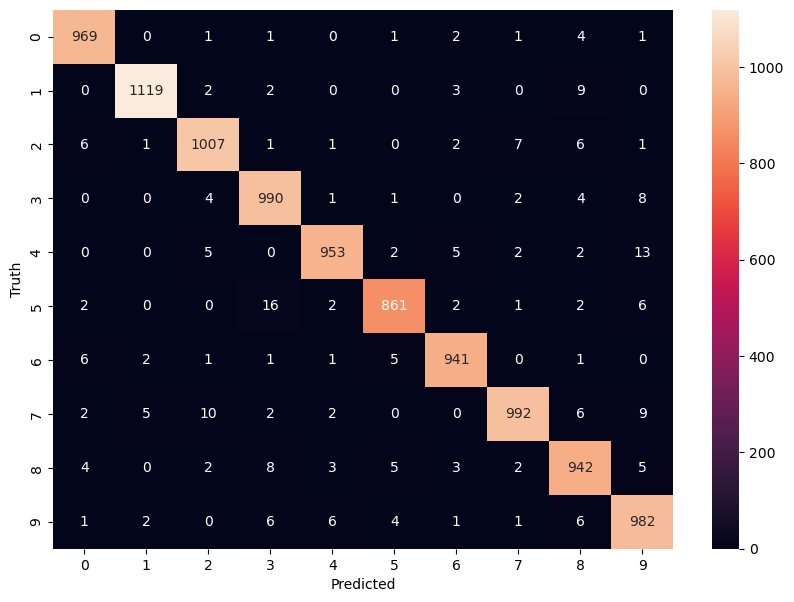

In [68]:
y_predicted = model.predict(x_test_flattened)
y_predicted_label = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_label)

import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

# No need for flattening
## Adding Input Layer

There is a method in keras which can do that work

In [79]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)), #input_shape=28x28 pixels
    keras.layers.Dense(100,activation='relu'), # no need to mention the input_shape as we did in the previous layer
    keras.layers.Dense(10, activation='sigmoid')
])
    
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


C:\Users\syamp\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8691 - loss: 0.4534
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9611 - loss: 0.1312
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9733 - loss: 0.0875
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0669
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9850 - loss: 0.0492
